In [1]:
import pandas

In [2]:
df = pandas.read_csv('PlayTennis.xls')

In [3]:
df.shape

(14, 5)

In [4]:
df.head()

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [5]:
df.isnull().sum()

outlook     0
temp        0
humidity    0
windy       0
play        0
dtype: int64

In [6]:
df.describe()

,outlook,temp,humidity,windy,play
count,14,14,14,14,14
unique,3,3,2,2,2
top,sunny,mild,high,False,yes
freq,5,6,7,8,9


In [14]:
X = df.iloc[:, 0: 4]

In [15]:
X

,outlook,temp,humidity,windy
0,sunny,hot,high,False
1,sunny,hot,high,True
2,overcast,hot,high,False
3,rainy,mild,high,False
4,rainy,cool,normal,False
5,rainy,cool,normal,True
6,overcast,cool,normal,True
7,sunny,mild,high,False
8,sunny,cool,normal,False
9,rainy,mild,normal,False


In [16]:
y = df.iloc[:, -1]

In [17]:
y

0      no
1      no
2     yes
3     yes
4     yes
5      no
6     yes
7      no
8     yes
9     yes
10    yes
11    yes
12    yes
13     no
Name: play, dtype: object

In [18]:
import sklearn.model_selection

In [25]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.naive_bayes import GaussianNB

In [27]:
model = GaussianNB()

**model.fit will throw an error as it only accepts float, and we are passing string 'overcast'**

**in such a case we use one hot encoding. why? because it is efficient that calculating the binary and its power required for calculating binary and takes less space than the label encoder which converts strings by sorting them alphabetically and giving an integer to each row.**

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
import numpy

In [43]:
one_hot_encoded = OneHotEncoder(sparse_output=False, dtype=numpy.int32)

**home task: write a function which will accept the values from the user for outlook, temp, humidity, wind and return the answer as PlayTenis or do not play**
**Find the suitable dataset for naive base algorithm and repeat all the steps for identified**

In [44]:
X_new = one_hot_encoded.fit_transform(X)

In [45]:
X_new.shape

(14, 10)

In [46]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X_new, y, test_size=0.2, random_state=42)

In [47]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

          no       0.50      1.00      0.67         1
         yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
cm = confusion_matrix(y_test, y_pred)

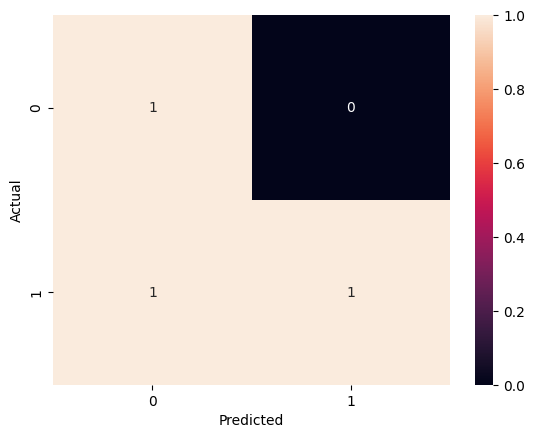

In [55]:

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [56]:
# Show class probabilities
print("Class priors:", model.class_prior_)
print("Feature probabilities:", model.theta_)

Class priors: [0.36363636 0.63636364]
Feature probabilities: [[0.         0.5        0.5        0.25       0.25       0.5
  0.75       0.25       0.25       0.75      ]
 [0.42857143 0.28571429 0.28571429 0.42857143 0.28571429 0.28571429
  0.28571429 0.71428571 0.71428571 0.28571429]]


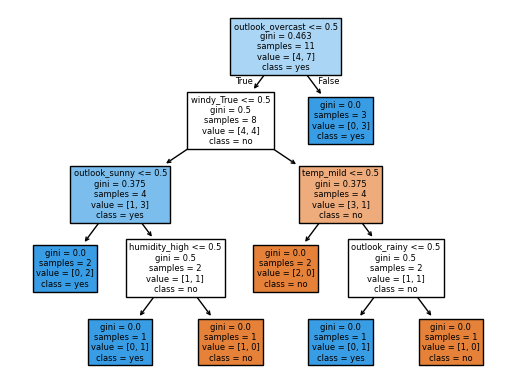

In [58]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
plot_tree(tree_model, feature_names=one_hot_encoded.get_feature_names_out(), class_names=model.classes_, filled=True)
plt.show()

In [63]:
def predict_play_tennis(outlook, temp, humidity, windy):
    import pandas as pd
    input_data = pd.DataFrame({
        'outlook': [outlook],
        'temp': [temp],
        'humidity': [humidity],
        'windy': [windy]
    })

    input_encoded = one_hot_encoded.transform(input_data)
    prediction = model.predict(input_encoded)
    return prediction[0]


In [68]:
result = predict_play_tennis('sunny', 'hot', 'high', True)
print(f"Prediction: {result}")

Prediction: no
